# Tendencias temáticas por palabra clave (2010–2025)

**Objetivo Específico 1** — Identificar los temas más tratados en la Chilean Journal of Statistics y
caracterizar su evolución a lo largo del período 2010–2025 (Sección 4.2 de la tesis).

A diferencia del notebook `04_clusterizacion_tematica.ipynb` —que agrupa los artículos completos en 7
clusters semánticos vía TF-IDF + LSA + K-means—, este análisis trabaja **a nivel de palabra clave
individual**: cada keyword declarada por los autores se sigue año a año, lo que permite detectar
tendencias emergentes o en declive con mayor granularidad que el análisis por cluster.

Para cada palabra clave se calculan (Sección 4.2.2.2 de la tesis):

- **freq_total** — suma de las proporciones anuales (peso relativo global).
- **persistencia** — número de años con presencia significativa (proporción > 0.01).
- **pendiente** — regresión lineal de la proporción anual frente al año.
- **año_pico / valor_pico** — momento y magnitud de mayor presencia.
- **año_medio** — año promedio de aparición, ponderado por frecuencia anual.
- **score** — combinación 70% freq_total + 30% persistencia, para priorizar temas frecuentes *y* sostenidos.

> **Nota metodológica:** la tesis agrupa manualmente algunas keywords sinónimas en "temas" (p. ej.
> *maximum likelihood* y *maximum likelihood estimation*) antes de graficar. Este notebook trabaja
> directamente a nivel de keyword normalizada (sin ese diccionario manual de sinónimos), por lo que
> los valores exactos pueden diferir levemente de la Figura 4.1 de la tesis, aunque el patrón general
> —qué temas crecen, cuáles son estables y cuáles declinan— es el mismo.


## 0. Configuración e imports

In [1]:

import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dateutil import parser as dtparser

DATA_JSON = Path("../data/reorganized_data_c_CLEAN_NORMALIZADO.json")
TABLES_DIR = Path("../results/tables"); TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGS_DIR = Path("../results/figures"); FIGS_DIR.mkdir(parents=True, exist_ok=True)

with open(DATA_JSON, "r", encoding="utf-8") as f:
    records = json.load(f)

print(f"Artículos cargados: {len(records)}")


Artículos cargados: 177


## 1. Construcción de la serie (año, keyword) en formato largo

La fecha real de publicación vive en el campo `fecha` (p. ej. "april, 2010"), no en un campo `year`
plano — se parsea con `dateutil`. Las keywords vienen concatenadas en un único string separado por
"·" (p. ej. `"Elliptically contoured · Kurtosis · Multivariate"`).


In [2]:

def get_year(rec):
    fecha = rec.get("fecha")
    if fecha:
        try:
            y = dtparser.parse(str(fecha), fuzzy=True).year
            if 1900 <= y <= 2100:
                return y
        except Exception:
            pass
    return None


rows, years_all = [], []
for i, rec in enumerate(records):
    year = get_year(rec)
    if not year:
        continue
    years_all.append({"article_id": i, "year": year})

    kw_raw = rec.get("keywords")
    if not kw_raw:
        continue
    for kw in kw_raw.split("·"):
        kw = kw.strip().lower().rstrip(".")
        if kw:
            rows.append({"article_id": i, "year": year, "keyword": kw})

df_kw = pd.DataFrame(rows)
df_years = pd.DataFrame(years_all).drop_duplicates()

print(f"Pares (artículo, keyword): {len(df_kw)}")
print(f"Keywords únicas: {df_kw['keyword'].nunique()}")
print(f"Artículos con año válido: {len(df_years)}")


Pares (artículo, keyword): 836
Keywords únicas: 690
Artículos con año válido: 177


## 2. Proporción anual por keyword

Para cada año se calcula qué fracción de los artículos publicados ese año mencionan cada keyword.
Esto permite comparar temas de frecuencia absoluta muy distinta en un mismo eje.


In [3]:

ALL_YEARS = sorted(df_years["year"].unique())
arts_per_year = df_years.groupby("year")["article_id"].nunique().rename("total_articulos")

counts = (df_kw.groupby(["year", "keyword"])["article_id"]
          .nunique().rename("n").reset_index()
          .merge(arts_per_year, on="year"))
counts["proporcion"] = counts["n"] / counts["total_articulos"]

# Solo se analizan keywords con al menos 3 apariciones en todo el período,
# para evitar que términos mencionados una sola vez dominen el ranking por "novedad".
MIN_APARICIONES = 3
keywords_validas = df_kw.groupby("keyword")["article_id"].nunique()
keywords_validas = keywords_validas[keywords_validas >= MIN_APARICIONES].index

print(f"Keywords con >= {MIN_APARICIONES} apariciones: {len(keywords_validas)}")


Keywords con >= 3 apariciones: 23


## 3. Métricas por tema (frecuencia, persistencia, pendiente, score)

In [4]:

UMBRAL_PRESENCIA = 0.01  # "presencia significativa" (Sección 4.2.2.2)
x_years = np.array(ALL_YEARS)

resultados = []
for kw in keywords_validas:
    serie = (counts[counts["keyword"] == kw]
             .set_index("year")["proporcion"]
             .reindex(ALL_YEARS, fill_value=0.0))
    y = serie.values

    pendiente = np.polyfit(x_years, y, 1)[0]
    freq_total = y.sum()
    persistencia = int((y > UMBRAL_PRESENCIA).sum())
    anio_pico = int(x_years[np.argmax(y)])
    valor_pico = float(y.max())
    anio_medio = float((x_years * y).sum() / y.sum()) if y.sum() > 0 else np.nan

    resultados.append({
        "keyword": kw, "freq_total": freq_total, "persistencia": persistencia,
        "pendiente": pendiente, "anio_pico": anio_pico, "valor_pico": valor_pico,
        "anio_medio": anio_medio,
    })

df_temas = pd.DataFrame(resultados)

# Score combinado: 70% frecuencia total + 30% persistencia (ambas normalizadas 0-1)
def normalizar(s):
    return (s - s.min()) / (s.max() - s.min()) if s.max() > s.min() else s * 0.0

df_temas["score"] = 0.7 * normalizar(df_temas["freq_total"]) + 0.3 * normalizar(df_temas["persistencia"])
df_temas = df_temas.sort_values("score", ascending=False).reset_index(drop=True)

df_temas.to_csv(TABLES_DIR / "tendencias_keywords.csv", index=False, encoding="utf-8-sig")
df_temas.head(15)


,keyword,freq_total,persistencia,pendiente,anio_pico,valor_pico,anio_medio,score
0,monte carlo simulation,1.170513,9,0.012606,2020,0.200000,2021.161738,1.000000
1,maximum likelihood estimation,1.020635,7,0.003877,2019,0.300000,2018.791602,0.803293
2,maximum likelihood,0.730037,6,-0.001446,2017,0.222222,2016.826392,0.545232
3,bayesian inference,0.653907,6,-0.003676,2017,0.222222,2015.588647,0.488854
4,censored data,0.470574,5,0.001796,2017,0.111111,2018.797353,0.310229
5,r software,0.476923,3,0.006086,2019,0.200000,2021.838710,0.229216
6,birnbaum-saunders distribution,0.411111,4,0.001748,2017,0.111111,2018.945946,0.223336
7,bootstrapping,0.383333,3,0.006250,2025,0.200000,2023.043478,0.159908
8,bias,0.325275,4,-0.002744,2016,0.100000,2014.631757,0.159770
9,symmetric distributions,0.360256,3,0.003365,2025,0.200000,2020.676157,0.142818


## 4. Bubble chart — pendiente vs. año medio (Gráfico 4.1)

Cada burbuja es un tema: posición horizontal = año medio de aparición, posición vertical = pendiente
de la tendencia, tamaño = frecuencia total acumulada. Se grafican los 25 temas con mayor `score`.


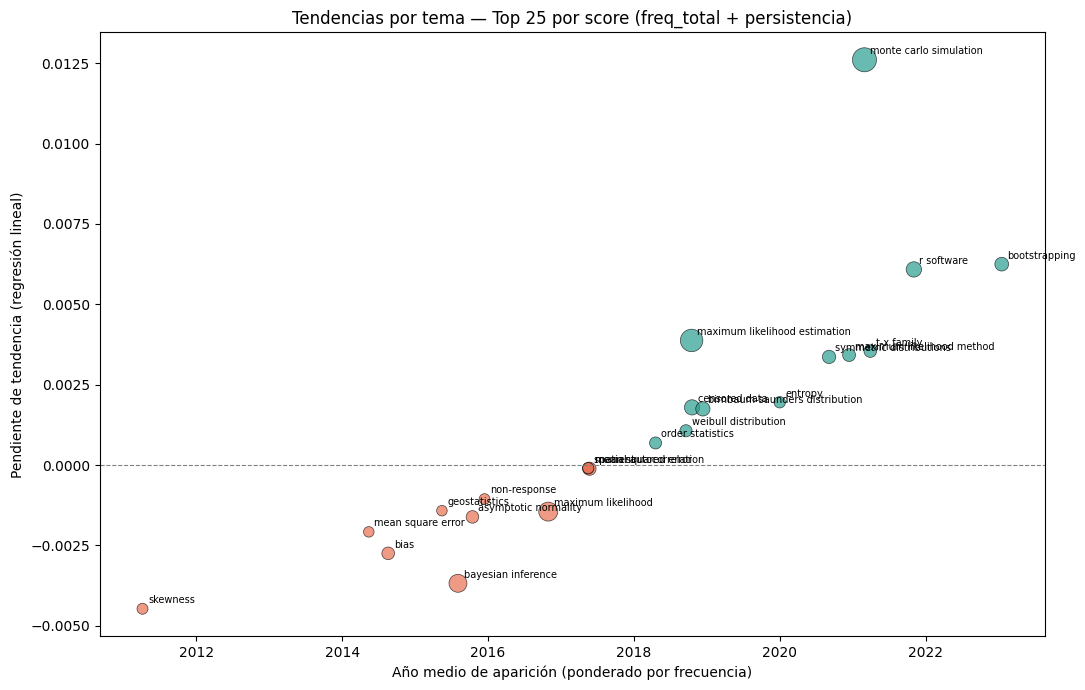

In [5]:

TOP_N = 25
top = df_temas.head(TOP_N)

fig, ax = plt.subplots(figsize=(11, 7))
sizes = 300 * (top["freq_total"] / top["freq_total"].max())
colors = np.where(top["pendiente"] >= 0, "#2a9d8f", "#e76f51")

ax.scatter(top["anio_medio"], top["pendiente"], s=sizes, c=colors, alpha=0.7, edgecolors="black", linewidths=0.5)
for _, row in top.iterrows():
    ax.annotate(row["keyword"], (row["anio_medio"], row["pendiente"]),
                fontsize=7, xytext=(4, 4), textcoords="offset points")

ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
ax.set_xlabel("Año medio de aparición (ponderado por frecuencia)")
ax.set_ylabel("Pendiente de tendencia (regresión lineal)")
ax.set_title(f"Tendencias por tema — Top {TOP_N} por score (freq_total + persistencia)")
fig.tight_layout()
fig.savefig(FIGS_DIR / "fig_4_1_bubble_tendencias_keywords.png", dpi=160)
plt.show()


## 5. Heatmap — presencia anual de los temas principales

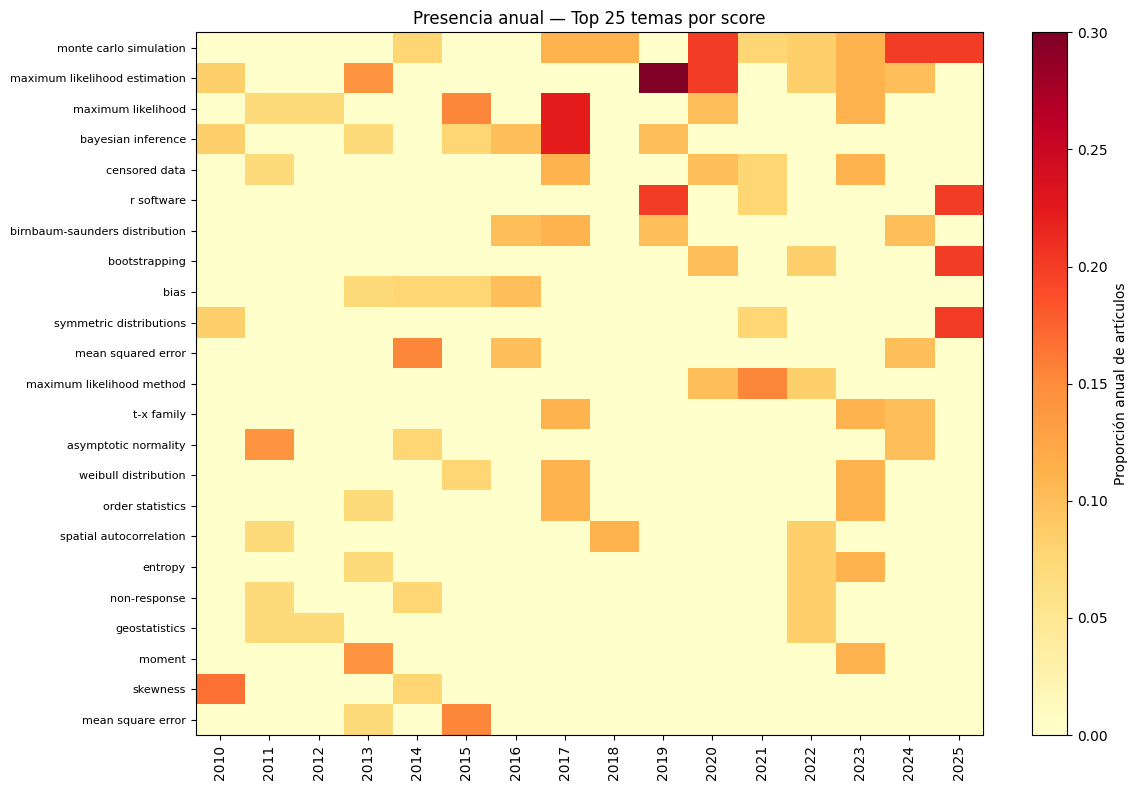

In [6]:

top_kw = df_temas.head(TOP_N)["keyword"].tolist()
heat = (counts[counts["keyword"].isin(top_kw)]
        .pivot(index="keyword", columns="year", values="proporcion")
        .reindex(index=top_kw, columns=ALL_YEARS)
        .fillna(0.0))

fig, ax = plt.subplots(figsize=(12, 8))
im = ax.imshow(heat.values, aspect="auto", cmap="YlOrRd")
ax.set_xticks(range(len(ALL_YEARS))); ax.set_xticklabels(ALL_YEARS, rotation=90)
ax.set_yticks(range(len(top_kw))); ax.set_yticklabels(top_kw, fontsize=8)
ax.set_title(f"Presencia anual — Top {TOP_N} temas por score")
fig.colorbar(im, ax=ax, label="Proporción anual de artículos")
fig.tight_layout()
fig.savefig(FIGS_DIR / "fig_4_1_heatmap_tendencias_keywords.png", dpi=160)
plt.show()


## 6. Lectura de resultados

Consistente con la Sección 4.2.3.2 de la tesis:

- **Temas en expansión reciente:** *bootstrapping* y *monte carlo simulation* muestran pendiente
  positiva y año medio posterior a 2020 — crecimiento acelerado en volúmenes recientes.
- **Temas históricos con reactivación:** *bayesian inference* combina un año medio relativamente
  temprano con score alto, reflejando un interés sostenido más que puntual.
- **Tendencia decreciente:** *maximum likelihood* y *bias* muestran pendiente negativa pese a alta
  frecuencia acumulada — temas consolidados que pierden peso relativo frente a líneas más nuevas.
- **Temas estables:** *censored data*, *geostatistics* y *order statistics* se ubican cerca de
  pendiente cero, con presencia sostenida pero sin cambios marcados.

Esta lectura a nivel de keyword es coherente con —y complementa a— el análisis de tendencias por
cluster del notebook `04_clusterizacion_tematica.ipynb`: allí el cluster de *inferencia paramétrica*
(el más numeroso, 50 artículos) es también el único, junto con *control estadístico de procesos*, con
pendiente positiva en el período 2010–2025.
